In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../macro_monthly_clean.csv", index_col=0, parse_dates=True)

df.head()

,cpi,unemployment,gdp,industrial_prod,fed_funds,personal_income,retail_sales,housing_starts,treasury_10y,treasury_2y
1954-07-31,26.86,5.8,390.996,18.0907,0.80,391.8,159177.0,1657.0,4.1,7.02
1954-10-31,26.72,5.7,399.734,18.3058,0.85,391.8,159177.0,1657.0,4.1,7.02
1955-01-31,26.77,4.9,413.073,19.2735,1.39,391.8,159177.0,1657.0,4.1,7.02
1955-04-30,26.79,4.7,421.532,20.2143,1.43,391.8,159177.0,1657.0,4.1,7.02
1955-07-31,26.76,4.0,430.221,20.7251,1.68,391.8,159177.0,1657.0,4.1,7.02


In [3]:
data = df.loc["1998-01-01":"2024-12-31"].copy()
data = data.dropna()

data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 324 entries, 1998-01-31 to 2024-12-31
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cpi              324 non-null    float64
 1   unemployment     324 non-null    float64
 2   gdp              324 non-null    float64
 3   industrial_prod  324 non-null    float64
 4   fed_funds        324 non-null    float64
 5   personal_income  324 non-null    float64
 6   retail_sales     324 non-null    float64
 7   housing_starts   324 non-null    float64
 8   treasury_10y     324 non-null    float64
 9   treasury_2y      324 non-null    float64
dtypes: float64(10)
memory usage: 27.8 KB


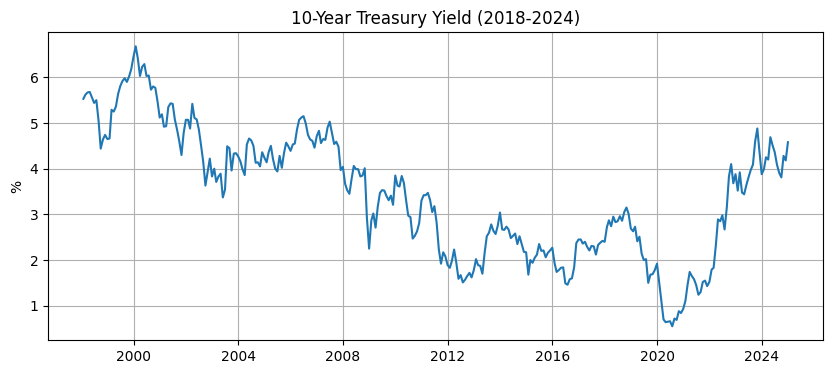

In [4]:
plt.figure(figsize=(10,4))
plt.plot(data.index, data["treasury_10y"], label="10Y Yield")
plt.title("10-Year Treasury Yield (2018-2024)")
plt.ylabel("%")
plt.grid(True)
plt.show()

In [7]:
train = data.loc[:"2007-7-31"]
test = data.loc["2007-8-1":"2010-01-01"]

X_train = train.drop(columns=["treasury_10y"])
y_train = train[["treasury_10y"]]

X_test = test.drop(columns=["treasury_10y"])
y_test = test[["treasury_10y"]]

print(train.shape, test.shape)

(115, 10) (29, 10)


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
mean_pred = np.ones_like(y_test) * np.mean(y_train)

baseline_rmse = np.sqrt(mean_squared_error(y_test, mean_pred))
baseline_rmse

np.float64(1.3673704094527181)

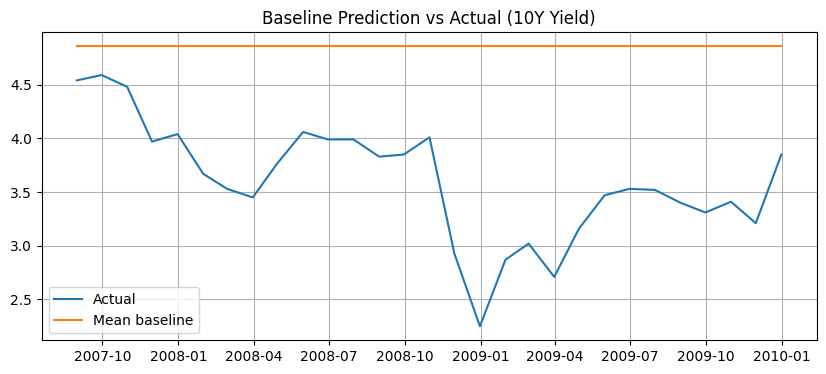

In [10]:
plt.figure(figsize=(10,4))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, mean_pred, label="Mean baseline")
plt.title("Baseline Prediction vs Actual (10Y Yield)")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# intercept
Xb = np.column_stack([np.ones(X_train_scaled.shape[0]), X_train_scaled])
Xt = np.column_stack([np.ones(X_test_scaled.shape[0]), X_test_scaled])

beta = np.linalg.pinv(Xb.T @ Xb) @ (Xb.T @ y_train.values)

beta[:5]

array([[ 4.85791304],
       [-0.11647785],
       [-0.0222234 ],
       [-1.46936419],
       [ 0.09009766]])

In [12]:
lr_pred = Xt @ beta
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_rmse

np.float64(0.8436000349221973)

In [13]:
lr_pred = Xt @ beta
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_rmse

np.float64(0.8436000349221973)

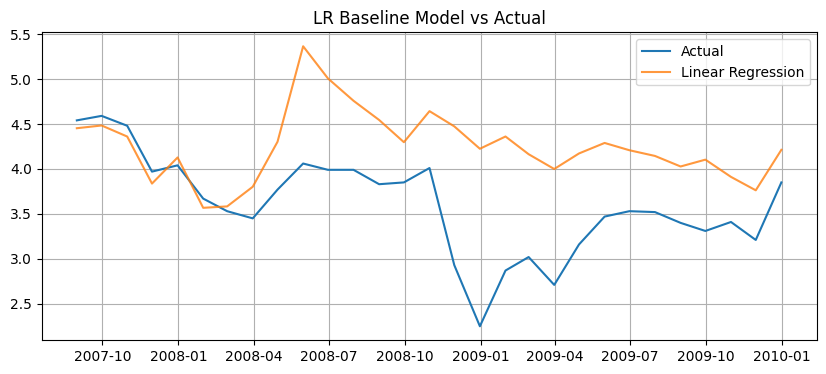

In [14]:
plt.figure(figsize=(10,4))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, lr_pred, label="Linear Regression", alpha=0.8)
plt.title("LR Baseline Model vs Actual")
plt.legend()
plt.grid(True)
plt.show()

In [52]:
class SimpleNN:
    def __init__(self, input_dim, hidden_dim=16, lr=0.001):
        self.W1 = np.random.randn(input_dim, hidden_dim) / np.sqrt(input_dim)
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, 2) / np.sqrt(hidden_dim)
        self.b2 = np.zeros(2)
        self.lr = lr

    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_deriv(self, x):
        return (x > 0).astype(float)

    def train(self, X, y, epochs=200):
        # y = y.reshape(-1, 1)

        for e in range(epochs):
            z1 = X @ self.W1 + self.b1
            a1 = self.relu(z1)
            z2 = a1 @ self.W2 + self.b2
            pred = z2
            
            # loss
            loss = np.mean((pred - y)**2)
            
            # back propagation
            dloss = 2 * (pred - y) / len(y)

            dW2 = a1.T @ dloss
            db2 = np.sum(dloss, axis=0)

            da1 = dloss @ self.W2.T
            dz1 = da1 * self.relu_deriv(z1)

            dW1 = X.T @ dz1
            db1 = np.sum(dz1, axis=0)

            # gradient descent
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2

    def predict(self, X):
        return self.relu(X @ self.W1 + self.b1) @ self.W2 + self.b2

In [60]:
nn = SimpleNN(input_dim=X_train_scaled.shape[1], hidden_dim=16, lr=0.001)

nn.train(X_train_scaled, y_train.values, epochs=300)

nn_pred = nn.predict(X_test_scaled)
nn_rmse = np.sqrt(mean_squared_error(y_test, nn_pred))
nn_rmse

np.float64(2.5962798559730755)

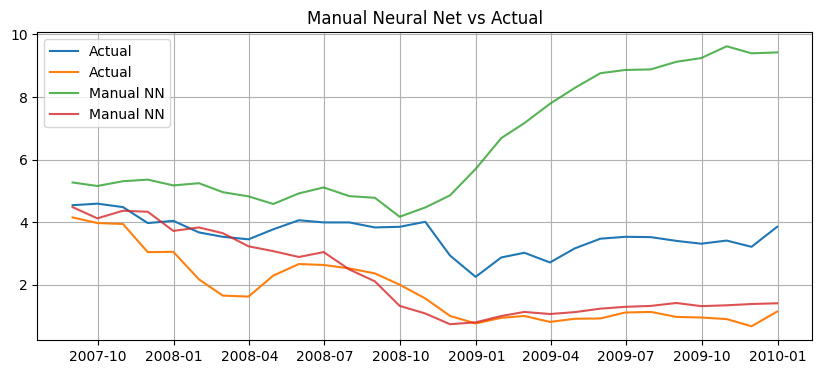

In [61]:
plt.figure(figsize=(10,4))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, nn_pred, label="Manual NN", alpha=0.8)
plt.title("Manual Neural Net vs Actual")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("BASELINE RMSEs (2018-2024 test period)")
print("--------------------------------------")
print(f"Mean baseline:         {baseline_rmse:.4f}")
print(f"Linear Regression:     {lr_rmse:.4f}")
print(f"Manual Neural Network: {nn_rmse:.4f}")


BASELINE RMSEs (2018-2024 test period)
--------------------------------------
Mean baseline:         2.0853
Linear Regression:     0.8757
Manual Neural Network: 0.3190
